descriptive statistics suffix:ll

Orig-ISP
  Count     : 135
  Mean      : 9.733059
  Std Dev   : 13.882743
  Min       : 0.726352
  Max       : 81.030449
  Median    : 3.610325

VO-ISP
  Count     : 135
  Mean      : 9.453932
  Std Dev   : 13.603342
  Min       : 0.696021
  Max       : 83.587715
  Median    : 3.243133

FO-ISP (Proxy)
  Count     : 135
  Mean      : 8.461779
  Std Dev   : 11.718082
  Min       : 0.631004
  Max       : 56.930752
  Median    : 2.791781

FO-ISP (CMA-ES)
  Count     : 135
  Mean      : 8.737262
  Std Dev   : 10.755301
  Min       : 0.638745
  Max       : 52.467743
  Median    : 3.959561


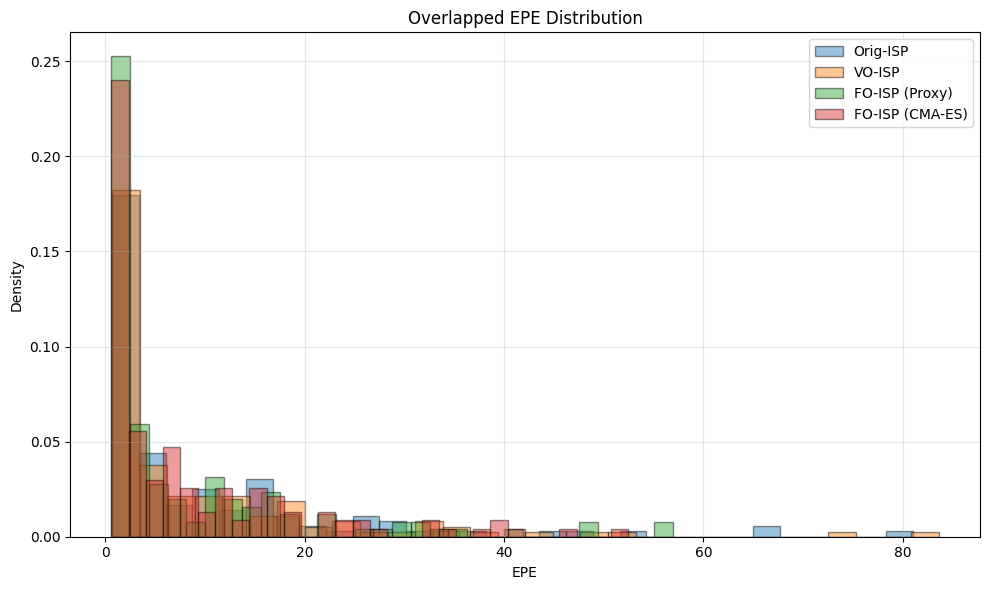

In [3]:
import itertools
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon
# ============================================================
# Input CSV paths
# ============================================================
# csv_paths = [
#     "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_sl_v16.2-chroma-ISPDefaultInitialHype_original_HpatchesV4.1",
#     "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_sl_v16.2-chroma-HumanTunedInitialHype_replicate-s21fe_sunlit_lr0.0005_schedulerPlateauTo0.00001_bs1_ga8_adjust_defaultcolorhuesat_120000_HpatchesV4.1",
#     "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_sl_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_sunlit_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32_105000_HpatchesV4.1",
#     "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_sl_CMAES_sunlit_maxstd0.01_CSA10.0_noiseaug0.6_2040_HpatchesV4.1"
# ]

csv_paths = [
    "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_ll_v16.2-chroma-ISPDefaultInitialHype_original_HpatchesV4.1",
    "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_ll_v16.2-chroma-HumanTunedInitialHype_replicate-s21fe_lowlight_lr0.0005_schedulerPlateauTo0.00001_bs1_ga8_adjust_defaultcolorhuesat_denoise_45000_HpatchesV4.1",
    "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_ll_FIXZEROGRADBUG_CFANORMALIZE_train_v16.2-chroma-HumanTunedInitialHype_lowlight_pooled480x640_allHomoRepeatedRaw_standardize_lr0.0005_gradac32_123000_HpatchesV4.1/",
    # "/home/boat/proxyISP/DGC-Net/proxydgc_eval/eval_ll_CMAES_lowlight_maxstd0.01_CSA10.0_noiseaug0.6_2300_HpatchesV4.1"
    "/home/boat/proxyISP/DGC-Net/proxydgc_eval_CMAES_train_lowlight_maxstd0.1_csadampfac1.5/eval_ll_CMAES_lowlight_maxstd0.1_CSA1.5_noiseaug0.6_2900_HpatchesV4.1"
]

exp_name = [
    "Orig-ISP",
    "VO-ISP",
    "FO-ISP (Proxy)",
    "FO-ISP (CMA-ES)"
]

img_suffix = "ll"

csv_paths = [os.path.join(i, "aepe_list.csv") for i in csv_paths]

# ============================================================
# Load CSVs
# ============================================================
dfs = {}
for i,path in enumerate(csv_paths):
    name = exp_name[i]
    df = pd.read_csv(path)

    # Ensure EPE column exists
    if "EPE" not in df.columns:
        raise ValueError(f"'EPE' column not found in {path}")

    dfs[name] = df

# ============================================================
# Print statistics
# ============================================================
print("=" * 60)
print("descriptive statistics suffix:" + img_suffix)
print("=" * 60)

for name, df in dfs.items():
    epe = df["EPE"]

    print(f"\n{name}")
    print(f"  Count     : {len(epe)}")
    print(f"  Mean      : {epe.mean():.6f}")
    print(f"  Std Dev   : {epe.std():.6f}")
    print(f"  Min       : {epe.min():.6f}")
    print(f"  Max       : {epe.max():.6f}")
    print(f"  Median    : {epe.median():.6f}")

# ============================================================
# Overlapped histogram
# ============================================================
plt.figure(figsize=(10, 6))

bins = 30

for name, df in dfs.items():
    plt.hist(
        df["EPE"],
        bins=bins,
        alpha=0.45,
        density=True,
        label=name,
        edgecolor="black"
    )

plt.xlabel("EPE")
plt.ylabel("Density")
plt.title("Overlapped EPE Distribution")
# plt.legend(
#     loc="upper center",
#     bbox_to_anchor=(0.5, 1.15),
#     ncol=1,
#     frameon=False
# )
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"figures/discriptive_stat_histograms_{img_suffix}.png")
plt.show()


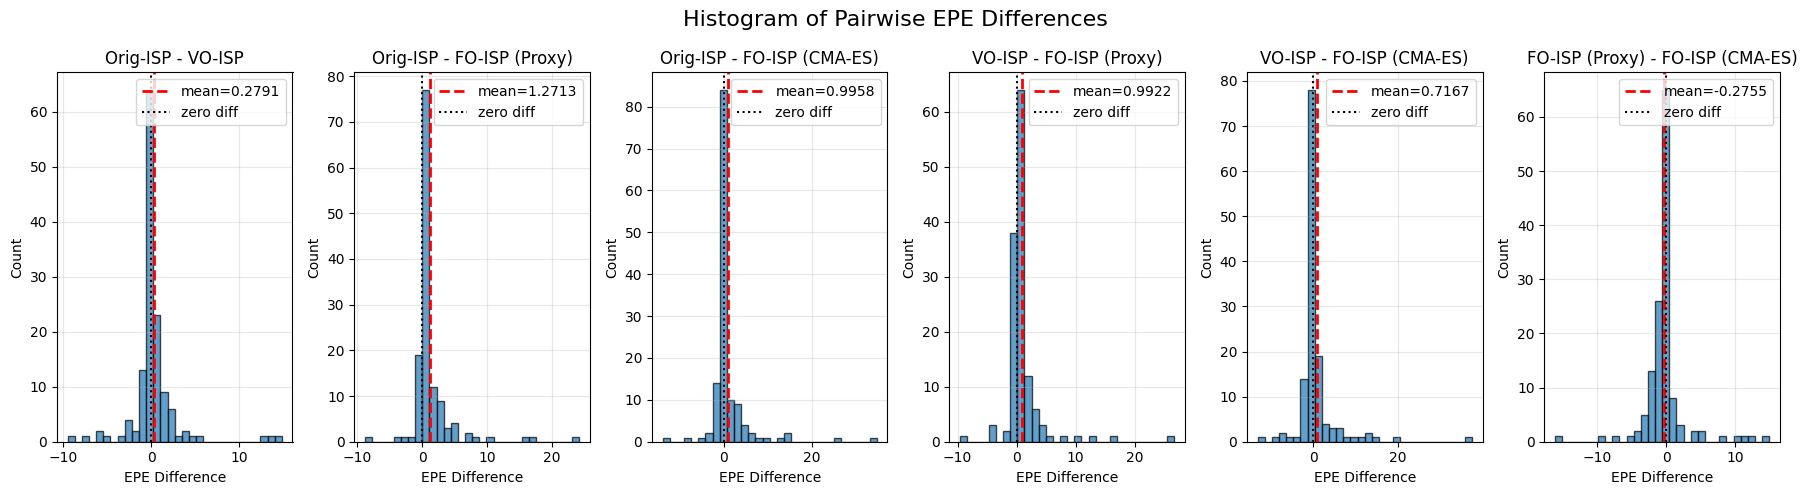

In [4]:
# ============================================================
# Plot histograms of pairwise differences
# diff = EPE(runA) - EPE(runB)
# ============================================================
pairs = list(itertools.combinations(dfs.keys(), 2))

fig, axes = plt.subplots(1, 6, figsize=(18, 5))

keys = ["Sequence Name", "Viewpoint"]

for ax, (name1, name2) in zip(axes, pairs):

    df1 = dfs[name1][keys + ["EPE"]].rename(columns={"EPE": "EPE_1"})
    df2 = dfs[name2][keys + ["EPE"]].rename(columns={"EPE": "EPE_2"})

    merged = pd.merge(df1, df2, on=keys, how="inner")

    diff = merged["EPE_1"] - merged["EPE_2"]

    ax.hist(
        diff,
        bins=30,
        alpha=0.7,
        edgecolor="black"
    )

    ax.axvline(
        diff.mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"mean={diff.mean():.4f}"
    )

    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1.5,
        label="zero diff"
    )

    ax.set_title(f"{name1} - {name2}")
    ax.set_xlabel("EPE Difference")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("Histogram of Pairwise EPE Differences", fontsize=16)

plt.tight_layout()
plt.show()

In [5]:
import itertools
import pandas as pd
from scipy.stats import wilcoxon
from IPython.display import display

# ============================================================
# Pairwise significance tests → DataFrame
# ============================================================

rows = []
alpha = 0.05

for a, b in itertools.combinations(dfs.keys(), 2):

    x = dfs[a]["EPE"].values
    y = dfs[b]["EPE"].values

    # Wilcoxon
    try:
        w_stat, w_p = wilcoxon(x, y)
    except ValueError:
        w_stat, w_p = float("nan"), float("nan")

    mean_a = x.mean()
    mean_b = y.mean()

    std_a = x.std(ddof=1)
    std_b = y.std(ddof=1)

    mean_diff = (x - y).mean()

    rows.append({
        "Parameter A": a,
        "Parameter B": b,

        "A (mean ± std)": f"{mean_a:.6f} ± {std_a:.6f}",
        "B (mean ± std)": f"{mean_b:.6f} ± {std_b:.6f}",

        "Mean Diff (A-B)": mean_diff,

        "Wilcoxon stat": w_stat,
        "Wilcoxon p": w_p,

        "p < 0.05": (
            w_p < alpha if pd.notna(w_p) else False
        )
    })

# Build DataFrame
result_df = pd.DataFrame(rows)

# Display
display(
    result_df.style.format({
        "Mean Diff (A-B)": "{:.6f}",
        "Wilcoxon stat": "{:.4f}",
        "Wilcoxon p": "{:.3e}",
    })
)

# Save
result_df.to_csv(
    f"pairwise_significance_{img_suffix}.csv",
    index=False
)

print(f"Saved → pairwise_significance_{img_suffix}.csv")

,Parameter A,Parameter B,A (mean ± std),B (mean ± std),Mean Diff (A-B),Wilcoxon stat,Wilcoxon p,p < 0.05
0,Orig-ISP,VO-ISP,9.733059 ± 13.882743,9.453932 ± 13.603342,0.279126,2023.0000,1.722e-08,True
1,Orig-ISP,FO-ISP (Proxy),9.733059 ± 13.882743,8.461779 ± 11.718082,1.271280,292.0000,3.744e-21,True
2,Orig-ISP,FO-ISP (CMA-ES),9.733059 ± 13.882743,8.737262 ± 10.755301,0.995797,2899.0000,2.041e-04,True
3,VO-ISP,FO-ISP (Proxy),9.453932 ± 13.603342,8.461779 ± 11.718082,0.992154,0.0000,6.714e-24,True
4,VO-ISP,FO-ISP (CMA-ES),9.453932 ± 13.603342,8.737262 ± 10.755301,0.716671,4427.0000,7.203e-01,False
5,FO-ISP (Proxy),FO-ISP (CMA-ES),8.461779 ± 11.718082,8.737262 ± 10.755301,-0.275483,1284.0000,3.847e-13,True


Saved → pairwise_significance_ll.csv


In [6]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from IPython.display import display

print("suffix", img_suffix)
alpha = 0.05

viewpoints = sorted(
    set().union(*[
        df["Viewpoint"].unique()
        for df in dfs.values()
    ])
)

all_tables = []

for vp in viewpoints:

    rows = []

    for a, b in itertools.combinations(dfs.keys(), 2):

        # filter viewpoint
        df_a = dfs[a][dfs[a]["Viewpoint"] == vp]
        df_b = dfs[b][dfs[b]["Viewpoint"] == vp]

        # pair by sequence
        merged = (
            df_a.merge(
                df_b,
                on=["Sequence Name", "Viewpoint"],
                suffixes=("_a", "_b")
            )
        )

        if merged.empty:
            continue

        x = merged["EPE_a"].values
        y = merged["EPE_b"].values

        try:
            w_stat, w_p = wilcoxon(x, y)
        except ValueError:
            w_stat, w_p = np.nan, np.nan

        rows.append({
            "Parameter A": a,
            "Parameter B": b,

            "A (mean ± std)":
                f"{x.mean():.4f} ± {x.std(ddof=1):.4f}",

            "B (mean ± std)":
                f"{y.mean():.4f} ± {y.std(ddof=1):.4f}",

            "Mean Diff":
                (x - y).mean(),

            "Wilcoxon stat":
                w_stat,

            "Wilcoxon p":
                w_p,

            "p < 0.05":
                (w_p < alpha)
                if pd.notna(w_p)
                else False,

            # "N":
            #     len(x)
        })

    vp_df = pd.DataFrame(rows)

    if vp_df.empty:
        continue

    # vp_df = vp_df.sort_values("Wilcoxon p")

    all_tables.append(
        vp_df.assign(Viewpoint=vp)
    )

    print("\n" + "=" * 80)
    print(f"VIEWPOINT {vp}")
    print("=" * 80)

    # display(
    #     vp_df.style.format({
    #         "Mean Diff": "{:.4f}",
    #         "Wilcoxon stat": "{:.2f}",
    #         "Wilcoxon p": "{:.3e}",
    #     })
    # )

    print(vp_df.to_string())

# save combined
final_df = pd.concat(all_tables, ignore_index=True)

path = f"pairwise_significance_by_viewpoint_{img_suffix}.csv"
final_df.to_csv(path, index=False)

print(f"\nSaved → {path}")

suffix ll

VIEWPOINT 2
      Parameter A      Parameter B   A (mean ± std)   B (mean ± std)  Mean Diff  Wilcoxon stat  Wilcoxon p  p < 0.05
0        Orig-ISP           VO-ISP  2.3520 ± 3.2566  2.0488 ± 2.7532   0.303184           61.0    0.001385      True
1        Orig-ISP   FO-ISP (Proxy)  2.3520 ± 3.2566  1.8779 ± 2.9824   0.474110           15.0    0.000002      True
2        Orig-ISP  FO-ISP (CMA-ES)  2.3520 ± 3.2566  2.0081 ± 2.6346   0.343924           99.0    0.029905      True
3          VO-ISP   FO-ISP (Proxy)  2.0488 ± 2.7532  1.8779 ± 2.9824   0.170926           96.0    0.024540      True
4          VO-ISP  FO-ISP (CMA-ES)  2.0488 ± 2.7532  2.0081 ± 2.6346   0.040740          167.0    0.610933     False
5  FO-ISP (Proxy)  FO-ISP (CMA-ES)  1.8779 ± 2.9824  2.0081 ± 2.6346  -0.130186          122.0    0.111051     False

VIEWPOINT 3
      Parameter A      Parameter B   A (mean ± std)   B (mean ± std)  Mean Diff  Wilcoxon stat    Wilcoxon p  p < 0.05
0        Orig-ISP         